###Параметры задачи и сетка

Задаём область расчёта и равномерную сетку.

1. **Геометрия и сетка**

Область:
$$
x \in [-L_x/2,\, L_x/2], \qquad
y \in [-L_y/2,\, L_y/2]
$$

Начальное поле функции тока для невозмущённого потока:
$$
\psi_0 = U_\infty\, y
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры задачи
U_inf = 1.0
R = 0.3
Lx = 4.0
Ly = 2.0

nx = 151
ny = 101

x = np.linspace(-Lx/2, Lx/2, nx)
y = np.linspace(-Ly/2, Ly/2, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y)

print("dx =", dx, "dy =", dy)
print("Размерность сетки:", X.shape)


dx = 0.026666666666666616 dy = 0.020000000000000018
Размерность сетки: (101, 151)


###Начальное поле ψ и граничные условия

Формируем цилиндр как твёрдую границу и задаём начальное поле ψ.

1. **Цилиндр как непроницаемая граница**

Маска цилиндра:
$$
x^2 + y^2 \le R^2
$$

На поверхности цилиндра:
$$
\psi = \psi_{\text{cyl}} = 0
$$

2. **Граничные условия канала**

На входе, выходе и стенках:
$$
\psi = U_\infty\, y
$$


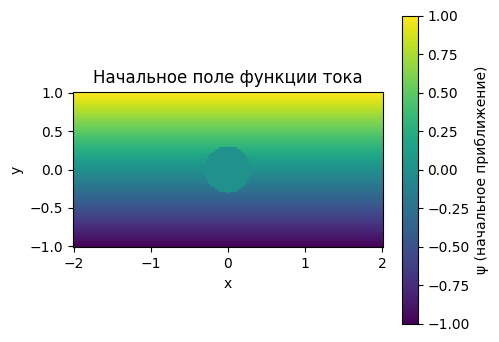

In [2]:

# Цилиндр расположен в центре: (0, 0)
cylinder_mask = X**2 + Y**2 <= R**2

# Начальное приближение: невозмущённый поток
psi = U_inf * Y.copy()

# Значение ψ на поверхности цилиндра (постоянная линия тока)
psi_cylinder = 0.0
psi[cylinder_mask] = psi_cylinder

def apply_boundary_conditions(psi_array):
    # левая и правая границы (x = const)
    psi_array[:, 0]  = U_inf * Y[:, 0]
    psi_array[:, -1] = U_inf * Y[:, -1]

    # нижняя и верхняя границы (y = const)
    psi_array[0, :]  = U_inf * Y[0, :]
    psi_array[-1, :] = U_inf * Y[-1, :]

    # поверхность цилиндра
    psi_array[cylinder_mask] = psi_cylinder

apply_boundary_conditions(psi)

plt.figure(figsize=(5, 4))
plt.pcolormesh(X, Y, psi, shading="auto")
plt.colorbar(label="ψ (начальное приближение)")
plt.gca().set_aspect("equal", "box")
plt.title("Начальное поле функции тока")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


###Решение уравнения Лапласа

Решаем уравнение для функции тока:

$$
\nabla^2 \psi = 0
$$

1. **Метод Якоби**

Итерационная формула:
$$
\psi^{(k+1)}_{i,j} =
\frac{1}{4}\left(
\psi^{(k)}_{i+1,j} +
\psi^{(k)}_{i-1,j} +
\psi^{(k)}_{i,j+1} +
\psi^{(k)}_{i,j-1}
\right)
$$

После каждой итерации фиксируются граничные условия.


In [3]:

max_iter = 8000
tolerance = 1e-5

for it in range(max_iter):
    psi_old = psi.copy()


    psi[1:-1, 1:-1] = 0.25 * (
        psi_old[2:, 1:-1] +
        psi_old[:-2, 1:-1] +
        psi_old[1:-1, 2:] +
        psi_old[1:-1, :-2]
    )

    apply_boundary_conditions(psi)

    diff = np.max(np.abs(psi - psi_old))

    if it % 500 == 0:
        print(f"Итерация {it}, max |Δψ| = {diff:.2e}")

    if diff < tolerance:
        print(f"Сходимость достигнута на итерации {it}, max |Δψ| = {diff:.2e}")
        break
else:
    print("Достигнут максимум итераций, решение может быть не полностью сходящимся.")


Итерация 0, max |Δψ| = 1.45e-01
Итерация 500, max |Δψ| = 1.14e-04
Итерация 1000, max |Δψ| = 4.10e-05
Итерация 1500, max |Δψ| = 1.75e-05
Сходимость достигнута на итерации 1867, max |Δψ| = 9.99e-06


###Вычисление скоростей и визуализация обтекания

Восстанавливаем поле скорости из найденной функции тока.

1. **Компоненты скорости**

$$
u = \frac{\partial \psi}{\partial y}, \qquad
v = -\frac{\partial \psi}{\partial x}
$$

Строим линии тока, распределение скорости и контур цилиндра.


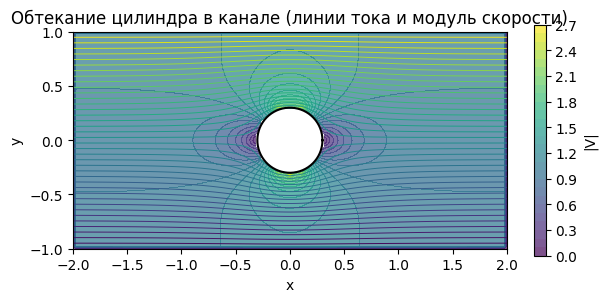

In [4]:

# u = ∂ψ/∂y,  v = -∂ψ/∂x
u = np.zeros_like(psi)
v = np.zeros_like(psi)

u[1:-1, 1:-1] = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2 * dy)
v[1:-1, 1:-1] = -(psi[1:-1, 2:] - psi[1:-1, :-2]) / (2 * dx)

u[cylinder_mask] = np.nan
v[cylinder_mask] = np.nan

speed = np.sqrt(u**2 + v**2)

plt.figure(figsize=(7, 3))

# Линии тока
levels = np.linspace(np.nanmin(psi), np.nanmax(psi), 40)
plt.contour(X, Y, psi, levels=levels, linewidths=0.7)

# Заливка по модулю скорости
plt.contourf(X, Y, speed, levels=30, alpha=0.7)
plt.colorbar(label="|V|")

theta = np.linspace(0.0, 2.0 * np.pi, 200)
xc = R * np.cos(theta)
yc = R * np.sin(theta)
plt.fill(xc, yc, color="white")
plt.plot(xc, yc, "k", linewidth=1.5)

plt.gca().set_aspect("equal", "box")
plt.title("Обтекание цилиндра в канале (линии тока и модуль скорости)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


###Скорость на центральной линии и аналитическое сравнение

Анализируем профиль скорости вдоль линии \( y = 0 \).

1. **Численная скорость**

$$
V = \sqrt{u^2 + v^2}
$$

2. **Аналитическое решение для обтекания цилиндра**

Для \( |x| > R \):
$$
V(x) = U_\infty \left( 1 - \frac{R^2}{x^2} \right)
$$

Сравниваем численный и аналитический профили.


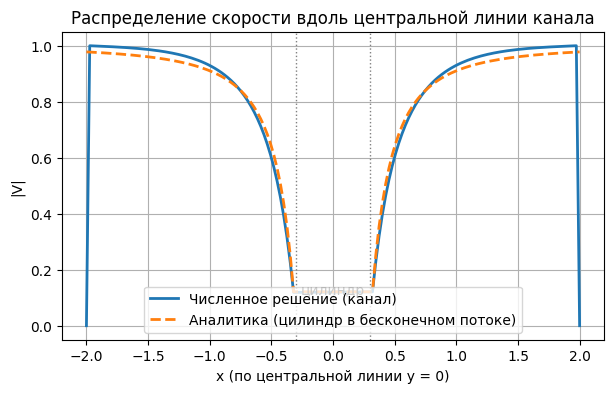

Среднеквадратичное отклонение (численное - аналитика) вдоль центральной линии: 0.12460914762326611


In [5]:

j_center = np.argmin(np.abs(y - 0.0))

x_centerline = x.copy()
speed_centerline = speed[j_center, :]

# Аналитика: обтекание цилиндра в бесконечном потоке, линия y = 0
analytic_speed = np.full_like(x_centerline, np.nan, dtype=float)

for i, xi in enumerate(x_centerline):
    if abs(xi) > R:  # только вне цилиндра
        analytic_speed[i] = U_inf * (1.0 - (R**2) / (xi**2))

fluid_mask = ~cylinder_mask[j_center, :]

plt.figure(figsize=(7, 4))
plt.plot(x_centerline[fluid_mask], speed_centerline[fluid_mask],
         label="Численное решение (канал)", linewidth=2)

valid_analytic = ~np.isnan(analytic_speed)
plt.plot(x_centerline[valid_analytic], analytic_speed[valid_analytic],
         "--", label="Аналитика (цилиндр в бесконечном потоке)", linewidth=2)

plt.axvline(-R, color="gray", linestyle=":", linewidth=1)
plt.axvline( R, color="gray", linestyle=":", linewidth=1)
plt.text(0.0, 0.1, "цилиндр", ha="center", va="bottom")

plt.xlabel("x (по центральной линии y = 0)")
plt.ylabel("|V|")
plt.title("Распределение скорости вдоль центральной линии канала")
plt.legend()
plt.grid(True)
plt.show()

valid = valid_analytic & fluid_mask
error = speed_centerline[valid] - analytic_speed[valid]
rms_error = np.sqrt(np.mean(error**2))
print("Среднеквадратичное отклонение (численное - аналитика) вдоль центральной линии:",
      rms_error)
